In [1]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(text_data)

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    return data

In [2]:
file_path = "../data/instruction-data.json"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"

data = download_and_load_file(file_path, url)
print(f"Number of entries: {len(data)}")

Number of entries: 1100


In [3]:
data[1]

{'instruction': 'Edit the following sentence for grammar.',
 'input': 'He go to the park every day.',
 'output': 'He goes to the park every day.'}

In [31]:
def format_input(entry, prompt_style="alpaca"):
    if prompt_style == "alpaca":
        instruction_text = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request."
            f"\n\n### Instruction:\n{entry['instruction']}"
        )

        input_text = (
            f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""
        )

        return instruction_text + input_text
    elif prompt_style == "phi-3":
        punc = entry['instruction'][-1]
        user_request = f"<|user|>\n{entry['instruction'][:-1]}"
        if entry['input']:
            user_request += f": {entry['input']}"
        else:
            user_request += punc
        return user_request
    else:
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")

In [25]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [26]:
model_input = format_input(data[50], prompt_style="phi-3")
desired_response = f"\n\n<|assistant|>\n{data[50]['output']}"
print(model_input + desired_response)

<|user|>
Identify the correct spelling of the following word: Ocassion

<|assistant|>
The correct spelling is 'Occasion.'


In [27]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

print("-------------")

model_input = format_input(data[999], prompt_style="phi-3")
desired_response = f"\n\n<|assistant|>\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.
-------------
<|user|>
What is an antonym of 'complicated'?

<|assistant|>
An antonym of 'complicated' is 'simple'.


In [42]:
def full_instruction_prompt(entry, prompt_style="alpaca"):
    model_input = format_input(entry, prompt_style)
    if prompt_style == "alpaca":
        desired_response = f"\n\n### Response:\n{entry['output']}"
    elif prompt_style == "phi-3":
        desired_response = f"\n\n<|assistant|>\n{entry['output']}"
    else:
        # This is actually impossible, but just in case (as model_input will already raise an input before we get into the if-else block)
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")
    return model_input + desired_response

In [77]:
# Exercise 6.2
def full_instruction_prompt_tokenize(entry, tokenizer, prompt_style="alpaca"):
    model_input_tokenized = tokenizer.encode(format_input(entry, prompt_style))
    if prompt_style == "alpaca":
        desired_response = f"\n\n### Response:\n{entry['output']}"
    elif prompt_style == "phi-3":
        desired_response = f"\n\n<|assistant|>\n{entry['output']}"
    else:
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")
    return model_input_tokenized, tokenizer.encode(desired_response)

In [81]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion+test_portion:]

print(f"Training set length: {len(train_data)}")
print(f"Validation set length: {len(val_data)}")
print(f"Test set length: {len(test_data)}")

Training set length: 935
Validation set length: 55
Test set length: 110


### Data Loaders

In [82]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer, prompt_style="alpaca"):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            self.encoded_texts.append(full_instruction_prompt_tokenize(entry, tokenizer, prompt_style))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)
            

In [83]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [84]:
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch) # 6
    inputs_lst = list()
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [85]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (inputs_1, inputs_2, inputs_3)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [86]:
# Now with the targets
def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = list(), list()

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [87]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [88]:
torch.nonzero((torch.tensor(batch[0]) == 1) | (torch.tensor(batch[0]) == 2)).shape

torch.Size([2, 1])

In [89]:
# Change the repeating "endoftext" tokens into -100 to discard them from loss calculation
# Because in pytorch, cross_entropy loss has -100 as the ignore index: cross_entropy(..., ignore_index=-100)
def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch) # Maximum length, including the "target" (so input sequence + 1)
    # and that +1 will make it possible to "shift" the text
    inputs_lst, targets_lst = list(), list()

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id] # Pre-emptively pad the sequence by 1
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item)) # It is padded until max(len(input)) + 1

        # Shift the sequence within itself to get the targets
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id # Mask for whereever we introduced the <|endoftext|> token
        indices = torch.nonzero(mask).squeeze() # torch.nonzero returns a 2D tensor, each row having the index of a nonzero value
        # i.e. the number of rows in the torch.nonzero(mask) is the number of non-zero elements in the sequence
        if indices.numel() > 1: # If the targets has more than 1 <|endoftext|>
            targets[indices[1:]] = ignore_index
        
        # Set to the context length of the model
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor


In [90]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [104]:
def custom_collate_fn(batch, pad_token_id=50256,
                      ignore_index=-100,
                      allowed_max_length=None,
                      device="cpu",
                      mask_instructions=False):
    batch_max_length = max(len(item[0] + item[1]) for item in batch) + 1
    inputs_lst, targets_lst = list(), list()

    for item in batch:
        instruction_length = len(item[0])
        new_item = item[0].copy() + item[1].copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if mask_instructions:
            targets[:instruction_length-1] = ignore_index
        
        # Set to the context length of the model
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [105]:
batch = (
    [[0, 1], [2, 3, 4]],
    [[5], [6]],
    [[7, 8, 9, 10], [11, 12, 13, 14, 15]]
)

In [106]:
inputs, targets = custom_collate_fn(batch, mask_instructions=True)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4, 50256, 50256, 50256, 50256],
        [    5,     6, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [    7,     8,     9,    10,    11,    12,    13,    14,    15]])
tensor([[ -100,     2,     3,     4, 50256,  -100,  -100,  -100,  -100],
        [    6, 50256,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
        [ -100,  -100,  -100,    11,    12,    13,    14,    15, 50256]])


In [115]:
device = torch.device("cuda")

In [108]:
from functools import partial

customized_collate_fn = partial(custom_collate_fn,
    device=device,
    allowed_max_length=1024)

instruction_masking_collate_fn = partial(custom_collate_fn,
    device=device,
    allowed_max_length=1024,
    mask_instructions=True)

In [111]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 2

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [110]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

In [ ]:
from gpt_download import download_and_load_gpt2
from gpt_modules import GPTModel
from weight_loader import load_weights_into_gpt

2025-11-29 22:49:14.805320: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-29 22:49:14.805904: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-29 22:49:14.860654: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-29 22:49:15.029885: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-29 22:49:16.951539: W tensorflow/compiler/tf2

In [113]:
BASE_CONFIG = {
    "vocab_size": 50_257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

model_configs = {
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16}
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size = model_size,
    models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 94.7kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:02<00:00, 360kiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 226kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [36:56<00:00, 640kiB/s]   
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 14.5MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:01<00:00, 586kiB/s] 
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 463kiB/s] 
2025-11-29 23:29:03.587173: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 205852672 exceeds 10% of free system memory.


In [114]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [116]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [117]:
from gpt_training_utils import generate, text_to_token_ids, token_ids_to_text

token_ids = generate(model=model,
                    idx=text_to_token_ids(input_text, tokenizer),
                    max_new_tokens=35,
                    context_size=BASE_CONFIG["context_length"],
                    eos_id=50256)

generated_text = token_ids_to_text(token_ids, tokenizer)

In [118]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [119]:
from gpt_training_utils import calc_loss_loader, train_model_with_bells_and_whistles

In [120]:
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [121]:
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print(f"Training Loss: {train_loss}")
print(f"Validation Loss: {val_loss}")

Training Loss: 3.782807779312134
Validation Loss: 3.7002232551574705


In [ ]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=5e-4, weight_decay=0.1
)
num_epochs=2
warmup_steps = int(0.2 * len(train_loader) * num_epochs)

train_losses, val_losses, track_tokens_seen, track_lrs = train_model_with_bells_and_whistles(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=5,
    eval_iter=1,
    start_context="Every effort moves you",
    tokenizer=tokenizer,
    warmup_steps=warmup_steps,
    initial_lr=1e-5,
    min_lr=1e-5,
)

end_time = time.time()
execution_time_mins = (end_time - start_time) / 60

Ep 1 (Iter 000000):  Train loss 3.204,  Val loss 3.388
Ep 1 (Iter 000005):  Train loss 2.157,  Val loss 2.219
Ep 1 (Iter 000010):  Train loss 1.331,  Val loss 1.392
Ep 1 (Iter 000015):  Train loss 0.967,  Val loss 1.235
Ep 1 (Iter 000020):  Train loss 0.667,  Val loss 1.033
Ep 1 (Iter 000025):  Train loss 0.912,  Val loss 1.009
Ep 1 (Iter 000030):  Train loss 0.641,  Val loss 1.019
Ep 1 (Iter 000035):  Train loss 0.840,  Val loss 1.069
Ep 1 (Iter 000040):  Train loss 0.775,  Val loss 1.043
Ep 1 (Iter 000045):  Train loss 0.781,  Val loss 1.072
Ep 1 (Iter 000050):  Train loss 0.671,  Val loss 1.038
Ep 1 (Iter 000055):  Train loss 0.951,  Val loss 1.047
Ep 1 (Iter 000060):  Train loss 1.056,  Val loss 1.167
Ep 1 (Iter 000065):  Train loss 0.685,  Val loss 1.116
Ep 1 (Iter 000070):  Train loss 0.599,  Val loss 1.169
Ep 1 (Iter 000075):  Train loss 0.457,  Val loss 1.221
Ep 1 (Iter 000080):  Train loss 0.881,  Val loss 1.331
Ep 1 (Iter 000085):  Train loss 0.557,  Val loss 1.167
Ep 1 (Iter

NameError: name 'execution_time_minutes' is not defined

In [126]:
print(f"Training completed in {execution_time_mins:.2f} minutes.")

Training completed in 223.39 minutes.


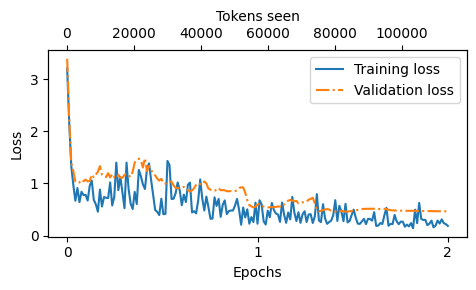

In [128]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

In [ ]:
torch.manual_seed(123)
for entry in test_data:
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size = BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text}")
    print("---------------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.
---------------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A thunderstorm is a type of atmospheric disturbance that produces strong winds, resulting in precipitation.
---------------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane 

🤔🤔  
  
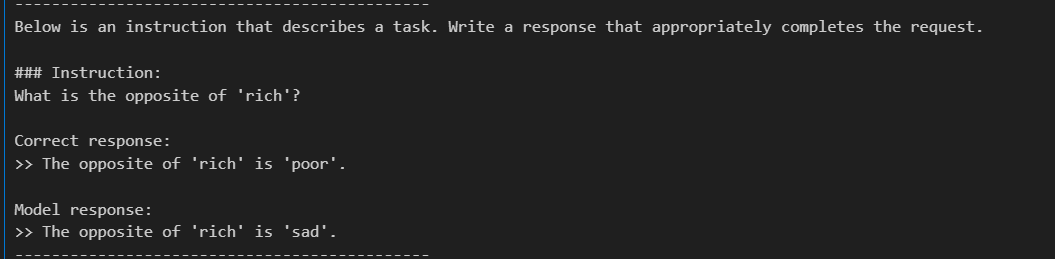

In [133]:
from tqdm import tqdm

In [134]:
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size = BASE_CONFIG["context_length"],
        eos_id=50256
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response.json", "w") as f:
    json.dump(test_data, f, indent=4)

100%|██████████| 110/110 [01:56<00:00,  1.06s/it]


In [135]:
import re

file_name = f"../models/{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as ../models/gpt2-medium355M-sft.pth


### TODO's

0. Rent an A100
1. Train instruction-ignored
2. Train Phi-3 style
3. Train Phi-3 and instruction-ignored
4. Add openrouter based verification (llm-as-a-judge)
5. Fine-tune on alpaca dataset
6. Add LoRA Layers and only tune lora params